# Time Series Forecasting with LSTM for Average Temperature

## Purpose
This notebook demonstrates how to build and train a Long Short-Term Memory (LSTM) neural network model to forecast average temperatures. The process involves loading historical temperature data, preprocessing it, training the LSTM model, and then making predictions on a test set to evaluate the model's performance.

## 1. Data Loading and Initial Inspection
In this section, we load the dataset, inspect its structure, check for missing values, and handle duplicates to ensure data quality.

### 1.1. Import Libraries
First, we import all the necessary libraries for data manipulation, visualization, and model building.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

### 1.2. Load Dataset
Load the `florida_file.csv` into a pandas DataFrame.

In [ ]:
df = pd.read_csv("/content/florida_file.csv")

### 1.3. Initial Data Overview
Display the first few rows of the DataFrame to understand its structure and content.

In [ ]:
df.head()

,Date,Avg_Temp,confidence_interval_temp,State,Country,Year,Month,Day
0,11/1/1743,17.694,2.514,Florida,United States,1743,11,1
1,12/1/1743,22.978,2.470,Florida,United States,1743,12,1
2,1/1/1744,22.978,2.470,Florida,United States,1744,1,1
3,2/1/1744,22.978,2.470,Florida,United States,1744,2,1
4,3/1/1744,22.978,2.470,Florida,United States,1744,3,1


### 1.4. DataFrame Information
Check the data types and non-null counts for each column.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      3239 non-null   object 
 1   Avg_Temp                  3239 non-null   float64
 2   confidence_interval_temp  3239 non-null   float64
 3   State                     3239 non-null   object 
 4   Country                   3239 non-null   object 
 5   Year                      3239 non-null   int64  
 6   Month                     3239 non-null   int64  
 7   Day                       3239 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 202.6+ KB


### 1.5. Data Dimensions
Display the number of rows and columns in the DataFrame.

In [ ]:
df.shape

(3239, 8)

### 1.6. Check for Missing Values
Verify if there are any missing values in the dataset.

In [ ]:
df.isnull().sum()

,0
Date,0
Avg_Temp,0
confidence_interval_temp,0
State,0
Country,0
Year,0
Month,0
Day,0


### 1.7. Check for Duplicate Rows
Ensure there are no duplicate entries in the dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

## 2. Data Preprocessing and Splitting
This section focuses on preparing the data for the LSTM model, including feature selection, splitting into training and testing sets, scaling, and creating input sequences.

### 2.1. Feature Selection and Renaming
We select only the 'Date' and 'Avg_Temp' columns and fill any potential missing values (though none were found in initial checks). Then, we rename columns for clarity.

In [ ]:
df = df[["Date","Avg_Temp"]]
df = df.fillna(df.bfill())
df.columns = ['Date','Avg_Temp']
df.head()

,Date,Avg_Temp
0,11/1/1743,17.694
1,12/1/1743,22.978
2,1/1/1744,22.978
3,2/1/1744,22.978
4,3/1/1744,22.978


### 2.2. Split Data into Training and Testing Sets
The data is split into training and testing sets based on the last 225 rows for testing.

In [ ]:
# Use first 3014 rows in train and next in test
train = df[:-225]
print(len(train))

3014


In [ ]:
test = df[-225:]
print(len(test))
test.head()

225


,Date,Avg_Temp
3014,1/1/1995,14.450
3015,2/1/1995,15.590
3016,3/1/1995,19.629
3017,4/1/1995,21.649
3018,5/1/1995,25.963


### 2.3. Convert Dates to Datetime Objects
Convert the 'Date' columns in both training and testing sets to datetime objects for easier manipulation and plotting.

In [ ]:
train_dates = pd.to_datetime(train['Date'])
test_dates  = pd.to_datetime(test['Date'])

### 2.4. Scale the Data
LSTM models perform better with scaled data. We use `MinMaxScaler` to scale the `Avg_Temp` values in the training set to a range between 0 and 1.

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(train['Avg_Temp'].values.reshape(-1,1))

### 2.5. Prepare Training Sequences
Create sequences of data for the LSTM model. Each `x_train` sequence will contain `prediction_days` (120) previous temperature values, and `y_train` will contain the temperature value to predict for the next day.

In [ ]:
# How many days of previous data to be considered while making predictions
prediction_days = 120

x_train = []
y_train = []

for x in range(0, len(scaled_data)-prediction_days):
    x_train.append(scaled_data[x:x+prediction_days, 0])
    y_train.append(scaled_data[x+prediction_days, 0])

### 2.6. Reshape Training Data
Convert the training lists to NumPy arrays and reshape `x_train` to a 3D format `(samples, timesteps, features)` which is required for LSTM layers.

In [ ]:
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

## 3. Model Building and Training
In this section, we define the LSTM model architecture, compile it, and train it using the prepared training data.

### 3.1. Build the LSTM Model
We construct a Sequential LSTM model with multiple LSTM layers and Dropout layers to prevent overfitting, followed by a Dense layer for the final prediction.

In [ ]:
# Build The Model
model = Sequential()

model.add(LSTM(units =64, activation='relu', return_sequences=True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(units =64, activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units =64, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Prediction of the next value

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 120, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 120, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,009 (324.25 KB)

 Trainable params: 83,009 (324.25 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2. Compile the Model
Compile the model using the 'adam' optimizer and 'mean_squared_error' as the loss function, suitable for regression tasks.

In [ ]:
model.compile(optimizer='adam',
              loss='mean_squared_error')

### 3.3. Train the Model
Train the LSTM model on the `x_train` and `y_train` data for a specified number of epochs. We also include a validation split to monitor performance on unseen data during training.

In [ ]:
history = model.fit(x_train, y_train, epochs = 15, batch_size=32, validation_split=0.1)

Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - loss: 0.0690 - val_loss: 0.0454
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0491 - val_loss: 0.0441
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0463 - val_loss: 0.0418
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0428 - val_loss: 0.0336
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0232 - val_loss: 0.0072
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0132 - val_loss: 0.0048
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0103 - val_loss: 0.0039
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0097 - val_loss: 0.0045
Epoch 9/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0088 - val_loss: 0.0040
Epoch 10/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0086 - val_loss: 0.0045
Epoch 11/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0084 - val_loss: 0.0043
Epoch 12/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s

### 3.4. Plot Training History
Visualize the training and validation loss over epochs to assess model convergence and identify potential overfitting.

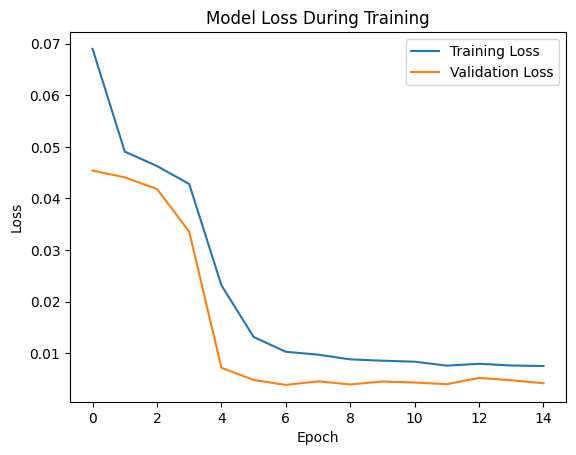

In [ ]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 4. Prediction and Evaluation
This section covers preparing the test data, making predictions with the trained model, inverse transforming the scaled predictions, and visualizing the results against actual values.

### 4.1. Prepare Test Data for Prediction
To make predictions on the test set, we need to create input sequences similar to the training data. This involves concatenating the relevant part of the training data with the test data and then scaling it.

In [ ]:
actual_temp = test['Avg_Temp'].values
total_temp = pd.concat((train['Avg_Temp'],
                        test['Avg_Temp']),
                        axis=0)

In [ ]:
prediction_days = 120

# Get the last 'prediction_days' values from the training data and all of the test data
# for the model inputs.
model_inputs = total_temp[len(total_temp) - len(test) - prediction_days:].values

model_inputs = model_inputs.reshape(-1,1)
model_inputs = scaler.transform(model_inputs)

### 4.2. Create `x_test` Sequences
Similar to `x_train`, we construct `x_test` by creating sequences of `prediction_days` previous values from `model_inputs`.

In [ ]:
# Make Predictions on Test Data
x_test = []

for x in range(prediction_days, len(model_inputs)):
    x_test.append(model_inputs[x-prediction_days:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

### 4.3. Generate Predictions
Use the trained LSTM model to make predictions on the prepared `x_test` data.

In [ ]:
pred = model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


### 4.4. Inverse Transform Predictions
Since the data was scaled before training, we need to inverse transform the predictions back to the original temperature scale.

In [ ]:
pred = scaler.inverse_transform(pred)

### 4.5. Add Predictions to Test DataFrame
Integrate the predicted temperatures into the `test` DataFrame for comparison.

In [ ]:
test['pred_temp'] = pred
test.head(20)

/tmp/ipykernel_1321/2972388115.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_temp'] = pred


,Date,Avg_Temp,pred_temp
3014,1/1/1995,14.450,14.835953
3015,2/1/1995,15.590,15.643350
3016,3/1/1995,19.629,17.896811
3017,4/1/1995,21.649,20.948191
3018,5/1/1995,25.963,24.030737
3019,6/1/1995,26.419,26.544460
3020,7/1/1995,28.000,27.976147
3021,8/1/1995,28.234,27.931585
3022,9/1/1995,26.966,25.791237
3023,10/1/1995,24.358,21.898777


### 4.6. Visualize Actual vs. Predicted Temperatures
Plot the actual and predicted temperatures over time to visually assess the model's forecasting accuracy.

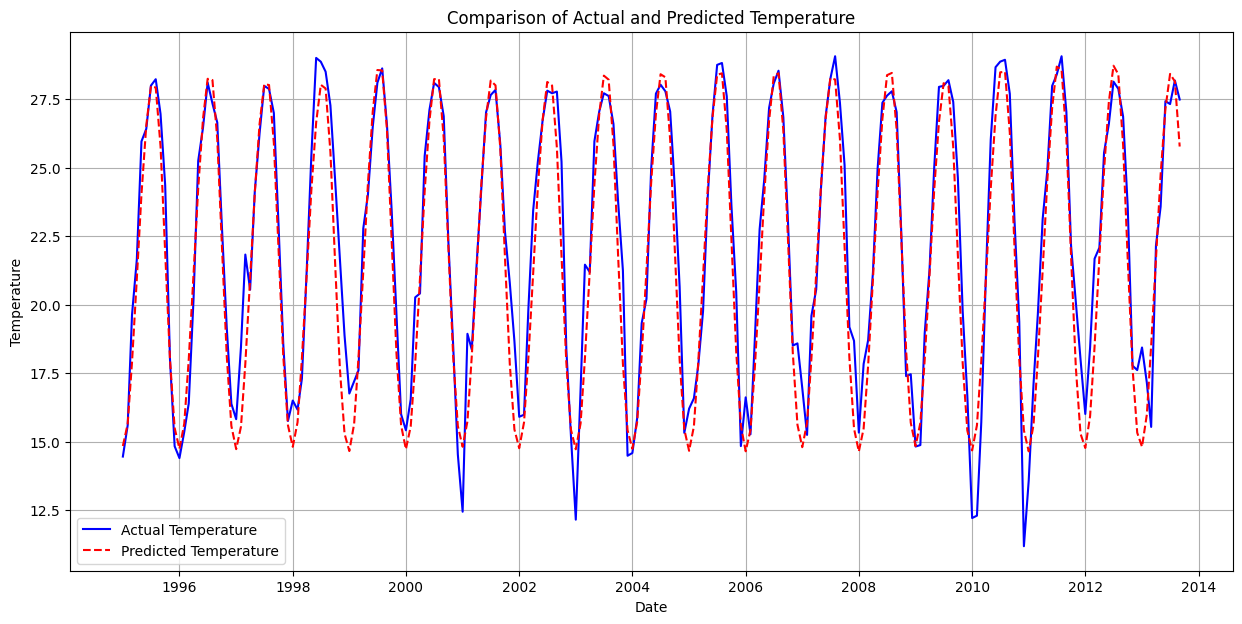

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test["Avg_Temp"], label="Actual Temperature", color='blue')
plt.plot(test_dates, test["pred_temp"], label="Predicted Temperature", color='red', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Comparison of Actual and Predicted Temperature")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion
This notebook successfully demonstrates a workflow for time series forecasting using an LSTM model. The model was able to learn patterns from historical temperature data and generate predictions for future temperatures. Further improvements could involve hyperparameter tuning, experimenting with different model architectures, or incorporating additional relevant features.